# Solucion 1: galaxia espiral y 04 ejercicios

Este notebook resuelve dos bloques:

- la parte de galaxia espiral inspirada en `00. Intro/Exersices_Python.ipynb`
- los tres ejercicios de `01. Fundamental Algorithms /01. Error and Differentiation/04. Ejercicios.ipynb`

La idea aqui es trabajar con codigo simple y legible, como lo escribiria un estudiante que quiere entender cada paso.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Parte A. Modelo sencillo de galaxia espiral

Uso una mezcla de gaussianas para el bulbo, el disco y la barra.
Luego agrego una modulacion suave para sugerir dos brazos espirales.


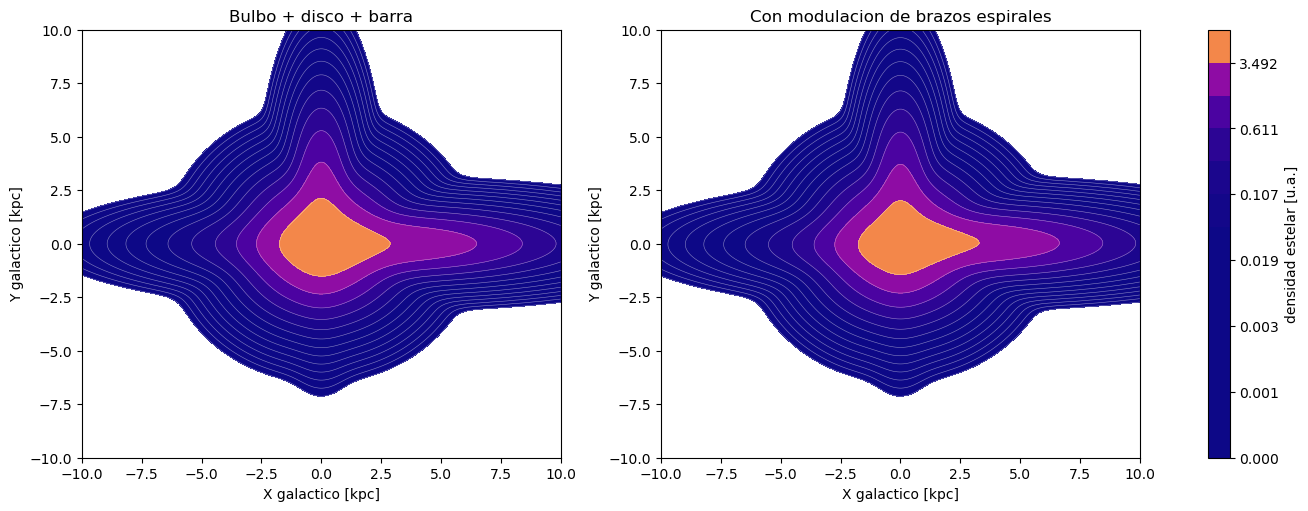

In [2]:
def gaussian_2d(x, y, x0, y0, sigma_x, sigma_y, amp):
    dx = (x - x0) ** 2 / (2 * sigma_x ** 2)
    dy = (y - y0) ** 2 / (2 * sigma_y ** 2)
    return amp * np.exp(-(dx + dy))


def spiral_modulation(x, y, arm_strength=0.28, arm_count=2, pitch_angle_deg=16):
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    pitch = np.deg2rad(pitch_angle_deg)
    phase = arm_count * (theta - np.log1p(r) * np.tan(pitch))
    return 1.0 + arm_strength * np.cos(phase)


x = np.linspace(-10, 10, 240)
y = np.linspace(-10, 10, 240)
X, Y = np.meshgrid(x, y)

bulge = gaussian_2d(X, Y, 0.0, 0.0, 1.4, 1.4, 5.0)
disk = gaussian_2d(X, Y, 2.8, 0.0, 3.2, 0.7, 2.7)
bar = gaussian_2d(X, Y, 0.0, 2.2, 0.6, 2.1, 1.7)

density_plain = bulge + disk + bar
density_spiral = bulge + disk * spiral_modulation(X, Y) + bar

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

levels_plain = np.logspace(np.log10(density_plain.min() + 1e-4), np.log10(density_plain.max()), 14)
levels_spiral = np.logspace(np.log10(density_spiral.min() + 1e-4), np.log10(density_spiral.max()), 14)

cf0 = axes[0].contourf(X, Y, density_plain, levels=levels_plain, cmap="plasma")
axes[0].contour(X, Y, density_plain, levels=levels_plain, colors="white", linewidths=0.4, alpha=0.5)
axes[0].set_title("Bulbo + disco + barra")
axes[0].set_xlabel("X galactico [kpc]")
axes[0].set_ylabel("Y galactico [kpc]")

cf1 = axes[1].contourf(X, Y, density_spiral, levels=levels_spiral, cmap="plasma")
axes[1].contour(X, Y, density_spiral, levels=levels_spiral, colors="white", linewidths=0.4, alpha=0.5)
axes[1].set_title("Con modulacion de brazos espirales")
axes[1].set_xlabel("X galactico [kpc]")
axes[1].set_ylabel("Y galactico [kpc]")

fig.colorbar(cf1, ax=axes, label="densidad estelar [u.a.]")
plt.show()


**Comentario corto:** `contourf` con niveles logaritmicos funciona mejor que `imshow` cuando la densidad cambia mucho entre el centro brillante y las zonas externas tenues.


## Parte B. Solucion de 04. Ejercicios


In [3]:
# Ejercicio 1
t = np.array([0.0, 0.5, 1.0, 1.5, 2.0])
v = np.array([200.0, 205.2, 210.8, 216.9, 223.5])
h_t = 0.5

a_inicio = (v[1] - v[0]) / h_t
a_final = (v[-1] - v[-2]) / h_t
a_centro = (v[3] - v[1]) / (2 * h_t)

print("Ejercicio 1")
print(f"Aceleracion en t0 con forward:  {a_inicio:.4f} km s^-2")
print(f"Aceleracion en t4 con backward: {a_final:.4f} km s^-2")
print(f"Aceleracion en t2 con centered: {a_centro:.4f} km s^-2")


Ejercicio 1
Aceleracion en t0 con forward:  10.4000 km s^-2
Aceleracion en t4 con backward: 13.2000 km s^-2
Aceleracion en t2 con centered: 11.7000 km s^-2


In [4]:
# Ejercicio 2
r = np.array([1.0, 1.1, 1.2, 1.3, 1.4])
p = np.array([10.00, 9.15, 8.20, 7.12, 5.90])
h_r = 0.1

grad_p = (3 * p[4] - 4 * p[3] + p[2]) / (2 * h_r)

print("Ejercicio 2")
print(f"dP/dr en r = 1.4: {grad_p:.4f} unidades arbitrarias por 10^3 km")


Ejercicio 2
dP/dr en r = 1.4: -12.9000 unidades arbitrarias por 10^3 km


In [5]:
# Ejercicio 3
d = np.array([10, 12, 14, 16, 18], dtype=float)
z = np.array([0.0020, 0.0035, 0.0055, 0.0080, 0.0110], dtype=float)
h_d = 2.0

dz_dD = (z[3] - z[1]) / (2 * h_d)
d2z_dD2 = (z[3] - 2 * z[2] + z[1]) / (h_d ** 2)

print("Ejercicio 3")
print(f"Primera derivada en D = 14 Mpc:  {dz_dD:.6f} Mpc^-1")
print(f"Segunda derivada en D = 14 Mpc: {d2z_dD2:.6f} Mpc^-2")


Ejercicio 3
Primera derivada en D = 14 Mpc:  0.001125 Mpc^-1
Segunda derivada en D = 14 Mpc: 0.000125 Mpc^-2


## Respuestas finales

- Ejercicio 1: `10.4`, `13.2` y `11.7 km s^-2`
- Ejercicio 2: `-12.9`
- Ejercicio 3: `0.001125 Mpc^-1` y `0.000125 Mpc^-2`
